# Access the analysis ready land cover data

This notebook provides an example of how to open the satellite-land-cover Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds-dev-cci2.copernicus-climate.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds-dev-cci2.copernicus-climate.eu/datasets/how-to-use-the-dss-arco-dataset).

In [ ]:
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [ ]:
import xarray as xr

# Time-chunked data for access optimised across spatial dimensions (e.g. a global map plot for a single time-step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-043/arco/satellite_land_cover/all/timeChunked.zarr"
 
# Open the timechunked_url with xarray.
ds = xr.open_zarr(
    timechunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 3TB
Dimensions:              (time: 31, latitude: 64800, longitude: 129600)
Coordinates:
  * time                 (time) datetime64[ns] 248B 1992-01-01 ... 2022-01-01
  * latitude             (latitude) float64 518kB -90.0 -90.0 ... 90.0 90.0
  * longitude            (longitude) float64 1MB -180.0 -180.0 ... 180.0 180.0
Data variables:
    change_count         (time, latitude, longitude) uint8 260GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    current_pixel_state  (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    lccs_class           (time, latitude, longitude) uint8 260GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    observation_count    (time, latitude, longitude) uint16 521GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    processed_flag       (time, latitude, longitude) float32 1TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    copernicus-support@ecmwf.int
    creation_date:              20240220T123148Z
    ...                         ...
    time_coverage_end:          20221231
    time_coverage_resolution:   P1Y
    time_coverage_start:        20220101
    title:                      Land Cover Map of 2022
    tracking_id:                cbc0983e-a0fd-4277-9023-2e618c0c2067
    type:                       C3S-LC-L4-LCCS-Map-300m-P1Y

Now we will plot the data with earthkit-plots.
The code cell below:
1. Extracts a sub-set of the data (UK and Ireland, 2020);
2. Creates an earthkit-plots style using the attributes in the data
3. Plots the data as a Categorical Map

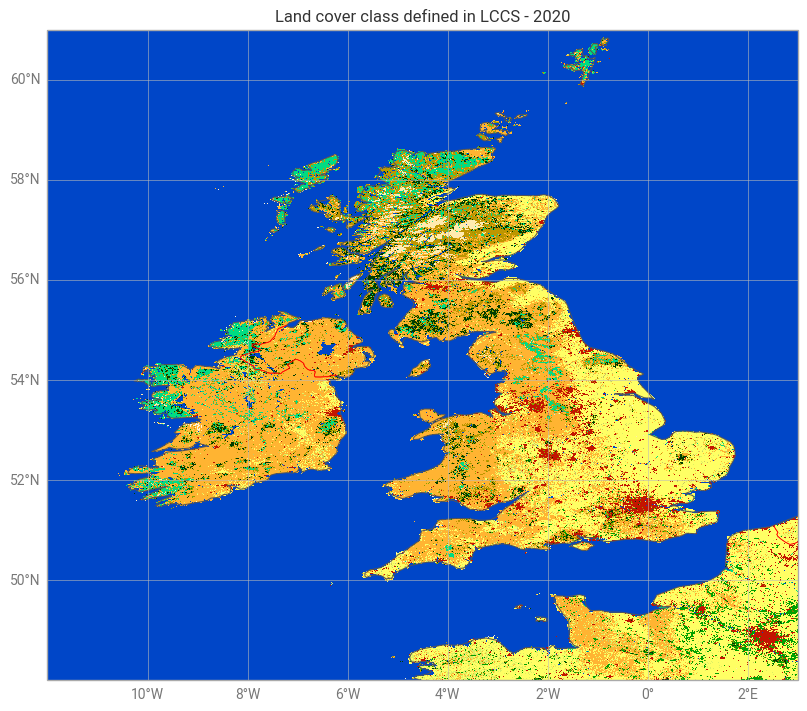

In [7]:
from earthkit import plots as ekp

# select a portion of the data to plot
lat_range = (48, 61)
lon_range = (-12, 3)
year = "2020"
lccs_class = ds.sel(latitude=slice(*lat_range), longitude=slice(*lon_range), time=year)["lccs_class"]

# Extract the levels and colors for the land cover classes from the dataset attributes
levels = lccs_class.attrs["flag_values"]
colors = lccs_class.attrs["flag_colors"].split(" ")
# Create an earthkit plot style for the land cover classes
style = ekp.styles.Categorical(
    levels=levels,
    colors=colors,
    legend_style=None,
)
chart = ekp.Map()

chart.grid_cells(lccs_class, style=style)

chart.coastlines()
chart.borders(color="red")
chart.gridlines()

chart.title("{variable_name} - "+str(year))

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [8]:
!pip install obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked data for access optimised along the time dimension (e.g. for time-series at a single point)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-002/arco/reanalysis_era5_single_levels/sfc/geoChunked.zarr"
  
# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 53TB
Dimensions:    (time: 755712, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-17T23:00:00
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables: (12/17)
    cbh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    fg10       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    skt        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    sp         (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    ...         ...
    tp         (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    u10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    u100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    v10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    v100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    blh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.